# 02 — Synthetic Data Cleaning & Target Construction

> ⚠️ **SYNTHETIC DATA — NOT REAL SURVEY RESPONSES**
>
> Applies the same cleaning and target-construction pipeline to the
> synthetic 1000-row dataset used in the real-data notebooks (02 + 03).

**Input:**  `data/synthetic/student_stress_synthetic_1000.csv`
**Output:** `data/synthetic/processed/student_stress_synthetic_clean.csv`

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic/student_stress_synthetic_1000.csv")
print("Loaded shape:", df.shape)

Loaded shape: (1000, 35)


## 1. Drop Unnecessary Columns

Drop `Timestamp`, the consent column, and the `Data_Source` marker.
Target: 32 remaining columns (matching the real cleaned dataset).

In [2]:
timestamp_col = "Timestamp"
consent_col = [c for c in df.columns if "Research Participation Consent" in c][0]
source_col = "Data_Source"

df = df.drop(columns=[timestamp_col, consent_col, source_col])
print("Shape after dropping:", df.shape)

Shape after dropping: (1000, 32)


## 2. Rename Columns to snake_case

Match the real-data pipeline naming so both datasets share identical
downstream processing code.

In [3]:
new_columns = [
    "age", "gender", "university", "program", "year", "cgpa",
    "study_hours", "attendance", "assignment_stress", "exam_count",
    "sleep_hours", "social_media", "physical_activity", "part_time_job",
    "screen_time", "financial_stress", "social_support",
    "stress_q1", "stress_q2", "stress_q3", "stress_q4", "stress_q5",
    "stress_q6", "stress_q7", "stress_q8", "stress_q9", "stress_q10",
    "academic_life_satisfaction", "biggest_stress_reason",
    "thought_break", "career_stress", "academic_performance",
]

assert len(new_columns) == df.shape[1], \
    f"Mismatch: {len(new_columns)} names vs {df.shape[1]} columns"

df.columns = new_columns
print("Renamed. Shape:", df.shape)
print("First 5:", df.columns[:5].tolist())
print("Last 5 :", df.columns[-5:].tolist())

Renamed. Shape: (1000, 32)
First 5: ['age', 'gender', 'university', 'program', 'year']
Last 5 : ['academic_life_satisfaction', 'biggest_stress_reason', 'thought_break', 'career_stress', 'academic_performance']


## 3. Reverse-Score Positively Worded Questions

Reverse `stress_q4, stress_q5, stress_q7, stress_q8` using:

In [4]:
reverse_cols = ["stress_q4", "stress_q5", "stress_q7", "stress_q8"]
for col in reverse_cols:
    df[col + "_rev"] = 6 - df[col]

final_stress_cols = [
    "stress_q1", "stress_q2", "stress_q3",
    "stress_q4_rev", "stress_q5_rev",
    "stress_q6",
    "stress_q7_rev", "stress_q8_rev",
    "stress_q9", "stress_q10",
]

df["stress_score"] = df[final_stress_cols].sum(axis=1)

print("Stress score stats:")
print(df["stress_score"].describe().round(2))

Stress score stats:
count    1000.00
mean       30.07
std        10.17
min        11.00
25%        21.00
50%        30.00
75%        39.00
max        50.00
Name: stress_score, dtype: float64


## 4. Create Target Variable (Tertile Split)

Split on the 33rd and 67th percentiles of the synthetic `stress_score`.
Gives a balanced 3-class target.

In [5]:
low_cut  = df["stress_score"].quantile(0.33)
high_cut = df["stress_score"].quantile(0.67)

print(f"Low cutoff  (33rd percentile): {low_cut}")
print(f"High cutoff (67th percentile): {high_cut}")

def categorize(score):
    if score <= low_cut:
        return "Low"
    elif score <= high_cut:
        return "Moderate"
    else:
        return "High"

df["stress_level"] = df["stress_score"].apply(categorize)

print()
print("Class distribution:")
print(df["stress_level"].value_counts())

Low cutoff  (33rd percentile): 24.0
High cutoff (67th percentile): 36.0

Class distribution:
stress_level
Moderate    342
Low         332
High        326
Name: count, dtype: int64


## 5. Save Cleaned Synthetic Data

In [6]:
os.makedirs("../data/synthetic/processed", exist_ok=True)
out_path = "../data/synthetic/processed/student_stress_synthetic_clean.csv"
df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape: {df.shape}")

Saved: ../data/synthetic/processed/student_stress_synthetic_clean.csv
Shape: (1000, 38)


## 6. Visualize Target Distribution


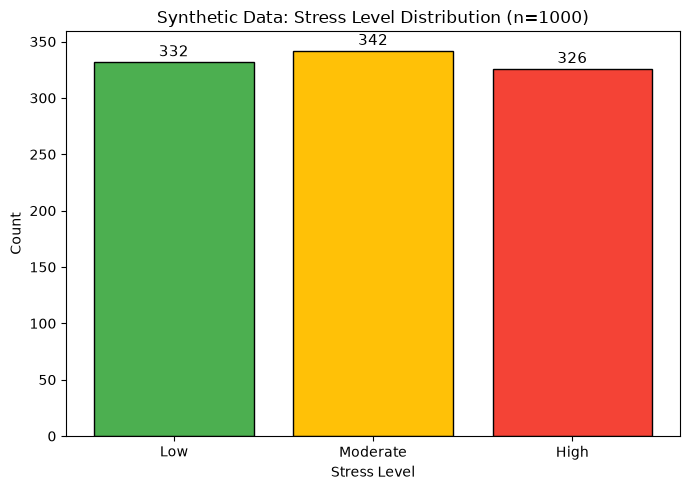

In [7]:
order = ["Low", "Moderate", "High"]
counts = df["stress_level"].value_counts().reindex(order)

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values,
                color=["#4CAF50", "#FFC107", "#F44336"],
                edgecolor="black")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 5,
             str(int(h)), ha="center", fontsize=11)

plt.title("Synthetic Data: Stress Level Distribution (n=1000)")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Summary

- ✅ Dropped 3 unnecessary columns → 32 features
- ✅ Renamed columns to match real pipeline
- ✅ Reverse-scored 4 positive questions
- ✅ Computed stress score
- ✅ Created balanced 3-class target
- ✅ Saved to `data/synthetic/processed/student_stress_synthetic_clean.csv`

**Next:** `03_synth_feature_engineering.ipynb`